# Forecasting using RNN networks

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Prepare Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", index_col=0)

In [3]:
print(data.head())
print(data.info())

                        open     high      low    close
date                                                   
2018-05-15 06:00:00  8733.86  8796.68  8707.28  8740.99
2018-05-15 07:00:00  8740.99  8766.00  8721.11  8739.00
2018-05-15 08:00:00  8739.00  8750.27  8660.53  8728.49
2018-05-15 09:00:00  8728.49  8754.40  8701.35  8708.32
2018-05-15 10:00:00  8708.32  8865.00  8695.11  8795.90
<class 'pandas.core.frame.DataFrame'>
Index: 58843 entries, 2018-05-15 06:00:00 to 2025-01-30 00:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    58843 non-null  float64
 1   high    58843 non-null  float64
 2   low     58843 non-null  float64
 3   close   58843 non-null  float64
dtypes: float64(4)
memory usage: 2.2+ MB
None


In [4]:
# Normalize the data 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [5]:
data_normalized

array([[0.0531995 , 0.05309288, 0.05342825, 0.05327592],
       [0.05326731, 0.05280399, 0.05356055, 0.05325699],
       [0.05324838, 0.05265587, 0.05298102, 0.05315703],
       ...,
       [0.95676786, 0.94963166, 0.95943854, 0.95457323],
       [0.9544189 , 0.95269199, 0.95997425, 0.95692256],
       [0.95696756, 0.94777663, 0.9605865 , 0.95624725]])

In [6]:
# Check data_normalized data type
print(type(data_normalized))

<class 'numpy.ndarray'>


In [7]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15

target_col_idx = data.columns.get_loc("close")
X, y = create_sequences(data_normalized, window_size, target_col_idx=target_col_idx)
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))  # Keep all features

### Split

In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (58828, 15, 4)
y shape: (58828,)


In [9]:
split = int(len(X) * 0.8)  # 80% training, 20% testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (47062, 15, 4)
y_train shape: (47062,)
X_test shape: (11766, 15, 4)
y_test shape: (11766,)


## Implementing GRU

In [10]:
gru_model = Sequential()

# First GRU layer with dropout
gru_model.add(GRU(30, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.3))

# Second GRU layer with dropout
gru_model.add(GRU(30, return_sequences=True))
gru_model.add(Dropout(0.3))

# Third GRU layer with dropout
gru_model.add(GRU(30, return_sequences=True))
gru_model.add(Dropout(0.3))

# Fourth GRU layer with dropout
gru_model.add(GRU(30))
gru_model.add(Dropout(0.3))

# Output layer: predicting only the close prices (1 feature)
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mean_squared_error')

gru_model.summary()

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 15, 30)         │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 15, 30)         │         5,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 15, 30)         │         5,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 30)             │         5,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,011 (78.17 KB)

 Trainable params: 20,011 (78.17 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss',  # Monitor validation loss
                               patience=5,          # Stop if no improvement for 5 epochs
                               restore_best_weights=True,  # Restore best model weights
                               verbose=1)           # Print message when stopping

# Train the GRU model with Early Stopping
history = gru_model.fit(X_train, y_train, 
                        epochs=30,  
                        batch_size=24, 
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  # Add Early Stopping
                        verbose=1)

Epoch 1/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0026 - val_loss: 0.0032
Epoch 2/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 5.9975e-04 - val_loss: 0.0041
Epoch 3/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 5.4694e-04 - val_loss: 0.0043
Epoch 4/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 5.0895e-04 - val_loss: 0.0056
Epoch 5/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 4.6513e-04 - val_loss: 0.0152
Epoch 6/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 4.5973e-04 - val_loss: 0.0174
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


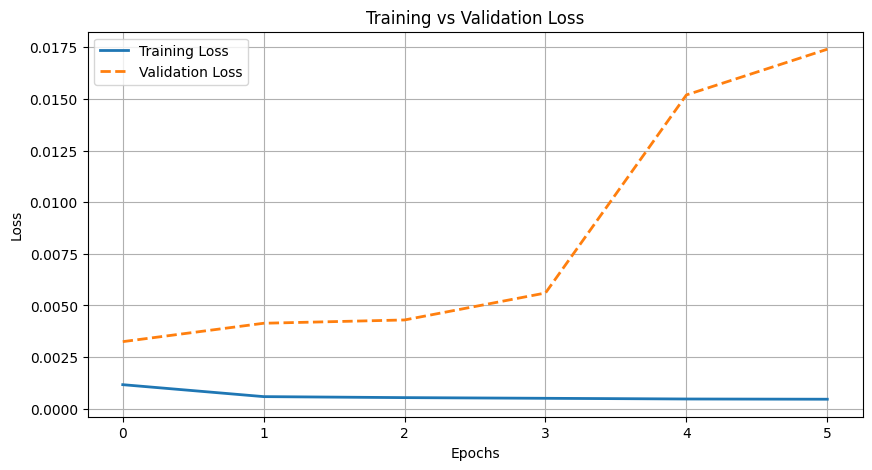

In [12]:
# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_gru = gru_model.predict(X_test)

# Inverse transform ONLY the close price column
predicted_gru = close_scaler.inverse_transform(predicted_gru.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Evaluate

In [14]:
# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_gru)
mse = mean_squared_error(y_test_actual, predicted_gru)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_gru) / y_test_actual)) * 100  # In percentage
r2 = r2_score(y_test_actual, predicted_gru)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 4739.8632
Mean Squared Error (MSE): 35895200.7810
Root Mean Squared Error (RMSE): 5991.2604
Mean Absolute Percentage Error (MAPE): 6.75%
R-squared (R²): 0.9094


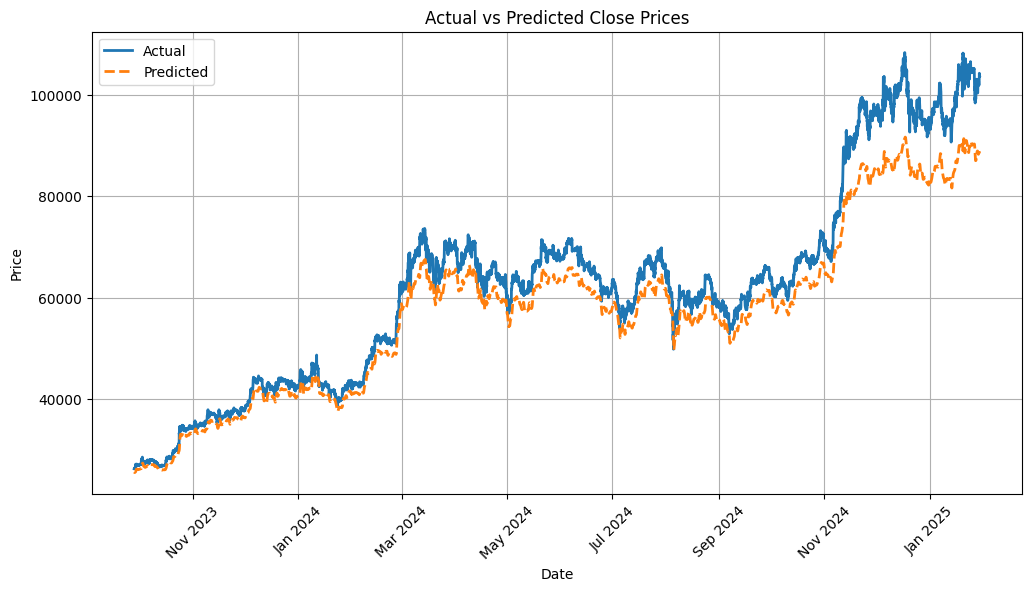

In [15]:
# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted with Month-Year Formatting
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_gru, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

# Format the x-axis to show both Month and Year (e.g., Jan 2021, Apr 2022)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Show every 2nd month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Jan 2021'

plt.xticks(rotation=45)  # Rotate labels for better readability
plt.legend()
plt.grid(True)
plt.show()

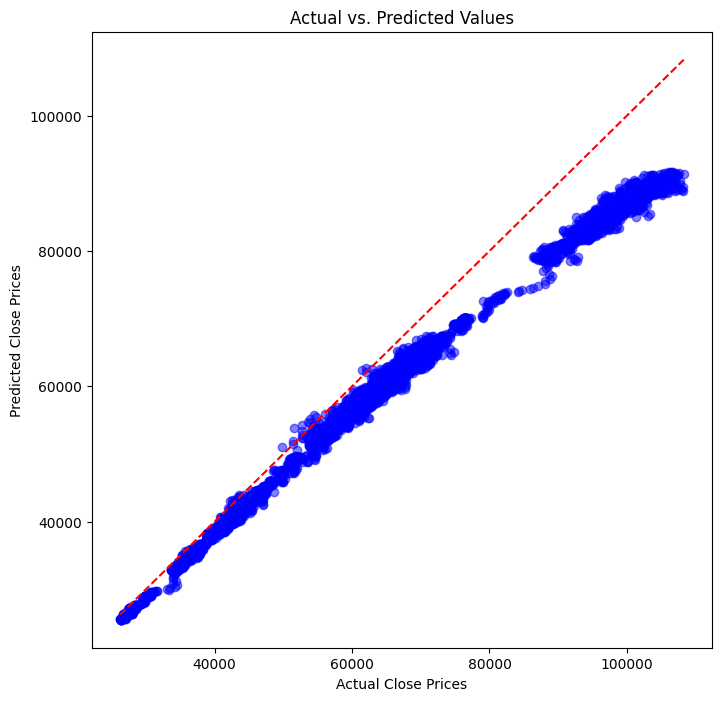

In [16]:
# Plot actual vs predicted values 
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, predicted_gru, alpha=0.5, color='blue')
plt.plot([min(y_test_actual), max(y_test_actual)], [min(y_test_actual), max(y_test_actual)], '--', color='red')  # Ideal line
plt.title("Actual vs. Predicted Values")
plt.xlabel("Actual Close Prices")
plt.ylabel("Predicted Close Prices")
plt.show()

## Hybrid LSTM-GRU model

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 15, 30)         │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 15, 30)         │         5,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 15, 30)         │         7,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 30)             │         5,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,711 (88.71 KB)

 Trainable params: 22,711 (88.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0025 - val_loss: 0.0010
Epoch 2/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 6.2292e-04 - val_loss: 0.0015
Epoch 3/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 5.5207e-04 - val_loss: 0.0030
Epoch 4/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 5.1908e-04 - val_loss: 0.0074
Epoch 5/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 5.0158e-04 - val_loss: 0.0120
Epoch 6/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 4.6858e-04 - val_loss: 0.0150
Epoch 7/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 4.8157e-04 - val_loss: 0.0149
Epoch 8/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 4.5069e-04 - val_loss: 0.0158
Epoch 9/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 4.6622e-04 - val_loss: 0.0157
Epoch 10/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 4.5816e-04 - val_loss: 0.0137
Epoch 11/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 4.4499e-0

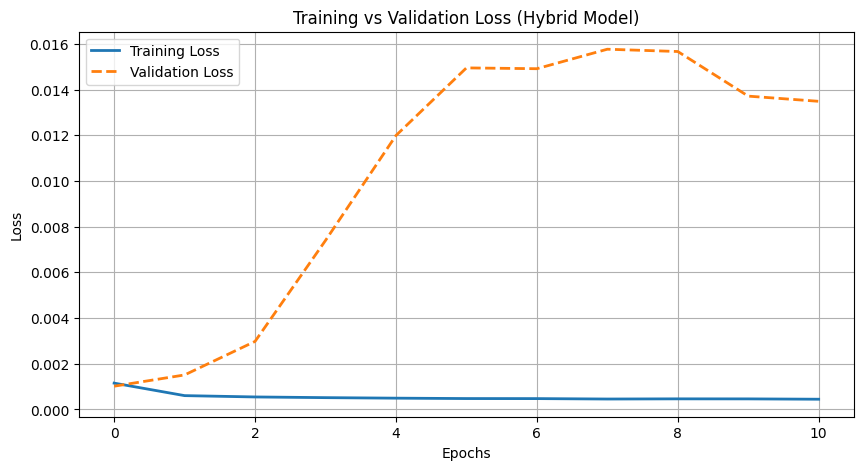

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Hybrid Model Error Statistics:
Mean Absolute Error (MAE): 2247.0904
Mean Squared Error (MSE): 11235861.1653
Root Mean Squared Error (RMSE): 3351.9936
Mean Absolute Percentage Error (MAPE): 3.05%
R-squared (R²): 0.9717


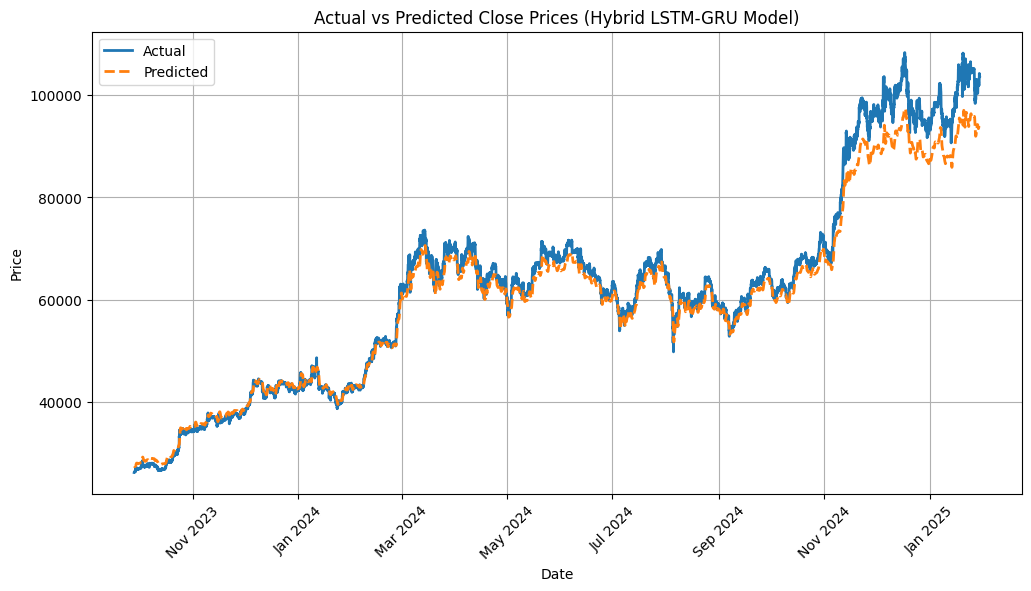

In [22]:
# Hybrid LSTM-GRU Model
hybrid_model = Sequential()

# First LSTM layer
hybrid_model.add(LSTM(30, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
hybrid_model.add(Dropout(0.3))

# First GRU layer
hybrid_model.add(GRU(30, return_sequences=True))
hybrid_model.add(Dropout(0.3))

# Second LSTM layer
hybrid_model.add(LSTM(30, return_sequences=True))
hybrid_model.add(Dropout(0.3))

# Second GRU layer
hybrid_model.add(GRU(30))
hybrid_model.add(Dropout(0.3))

# Output layer
hybrid_model.add(Dense(1))

# Compile the model
hybrid_model.compile(optimizer='adam', loss='mean_squared_error')

# Model Summary
hybrid_model.summary()

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the Hybrid Model
history_hybrid = hybrid_model.fit(X_train, y_train, 
                                  epochs=30,  
                                  batch_size=24, 
                                  validation_data=(X_test, y_test), 
                                  callbacks=[early_stopping],  
                                  verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history_hybrid.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Hybrid Model)')
plt.legend()
plt.grid(True)
plt.show()

# Make predictions
predicted_hybrid = hybrid_model.predict(X_test)

# Inverse transform the predicted and actual values using the correct scaler
predicted_hybrid = close_scaler.inverse_transform(predicted_hybrid)
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate model performance
mae = mean_absolute_error(y_test_actual, predicted_hybrid)
mse = mean_squared_error(y_test_actual, predicted_hybrid)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_hybrid) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_hybrid)

# Print results
print(f"Hybrid Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_hybrid, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Hybrid LSTM-GRU Model)')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Implementing LSTM

In [18]:
# lstm_model = Sequential()

# # First LSTM layer with dropout
# lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
# lstm_model.add(Dropout(0.2))

# # Second LSTM layer with dropout
# lstm_model.add(LSTM(50, return_sequences=True))
# lstm_model.add(Dropout(0.2))

# # Third LSTM layer with dropout
# lstm_model.add(LSTM(50, return_sequences=True))
# lstm_model.add(Dropout(0.2))

# # Fourth LSTM layer with dropout
# lstm_model.add(LSTM(50))
# lstm_model.add(Dropout(0.2))

# # Output layer
# lstm_model.add(Dense(1))

# lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# lstm_model.summary()

In [19]:
# # Training 
# lstm_model.fit(X_train, y_train, epochs=30, batch_size=24, verbose=1)

In [20]:
# # Visualizing LSTM Model Predictions: Comparing Actual and Predicted Data

# # Make predictions
# predicted_lstm = lstm_model.predict(X_test)

# # Inverse transform the predicted and actual values using the correct scaler
# predicted_lstm = close_scaler.inverse_transform(predicted_lstm)  # Use close_scaler
# y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))  # Ensure correct shape

# # Extract the date index for the test set
# date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# # Plot Actual vs Predicted Prices
# plt.figure(figsize=(12, 6))
# plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
# plt.plot(date_index, predicted_lstm, label='Predicted', linewidth=2, linestyle='dashed')

# plt.title('Actual vs Predicted Close Prices')
# plt.xlabel('Date')
# plt.ylabel('Price')

# # Format x-axis to show Month-Year
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Show every 2nd month
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Jan 2021'

# plt.xticks(rotation=45)  # Rotate labels for better readability
# plt.legend()
# plt.grid(True)
# plt.show()

In [21]:
# # Compute error metrics
# mae = mean_absolute_error(y_test_actual, predicted_lstm)
# mse = mean_squared_error(y_test_actual, predicted_lstm)
# rmse = np.sqrt(mse)
# mape = np.mean(np.abs((y_test_actual - predicted_lstm) / y_test_actual)) * 100  # In percentage
# r2 = r2_score(y_test_actual, predicted_lstm)

# # Print results
# print(f"Model Error Statistics:")
# print(f"Mean Absolute Error (MAE): {mae:.4f}")
# print(f"Mean Squared Error (MSE): {mse:.4f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
# print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
# print(f"R-squared (R²): {r2:.4f}")